**Aluno:** Otávio Augusto Reis Nascimento<br>
**Projeto:** hotel_bookingsAI

# Bibliotecas para manipulação de dados

In [1]:
import pandas as pd
import numpy as np

#Visualização de Dados

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning (Scikit-learn)

**Pré Processamento:**
<br>
LabelEncoder, converte categorias em números inteiros.
<br>
OneHotEncoder, cria variáveis binárias para categorias (dummy variables).
<br>
StandardScaler, normaliza os dados para média 0 e variância 1.
<br>
SimpleImpute, preenche valores ausentes (missing values) com média, mediana ou valor constante.
<br>
<br>
**Modelos de Classificação**
<br>
RandomForestClassifier, modelo baseado em múltiplas árvores de decisão (ensemble).
<br>
DecisionTreeClassifier, modelo simples baseado em árvore de decisão.
<br>
<br>
**Métricas de Avaliação**
<br>
accuracy_score, mede a proporção de acertos.
<br>
confusion_matrix, mostra erros e acertos por classe.
<br>
classification_report, resume precisão, recall e F1-score.
<br>
<br>
**Transformações e Pipelines**
<br>
ColumnTransformer, aplica diferentes transformações em colunas específicas.
<br>
Pipeline, Encadeia etapas (pré-processamento + modelo) em um fluxo único.
<br>
<br>
**Adicionais**
<br>
warnings, controla mensagens de aviso do Python.Oculta avisos para deixar a saída mais limpa.
<br>
plt.style.use('seaborn'), define o estilo visual dos gráficos para o padrão do seaborn (mais agradável e moderno).
<br><br>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

#Upload e carregamento do Dataset, arquivo no Colab

In [4]:
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [5]:
df = pd.read_csv('hotel_bookings.csv')

# Visualização inicial, informações e estatísticas descritivas

In [6]:
df.head() # visualizar primeiras linhas
df.info() # tipos e contagem não-nulas
df.describe(include='all').T # estatísticas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


#Verificação de nulos e Duplicados

In [7]:
df.isnull().sum() # contagem de nulos por coluna
df.duplicated().sum() # número de linhas duplicadas

np.int64(31994)

Foi encontrado 31.994 linhas duplicadas.

#Removendo Duplicatas

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

#Conversão de datas

In [11]:
if {'arrival_date_year','arrival_date_month','arrival_date_day_of_month'}.issubset(df.columns):
    meses = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
    df['arrival_month_num'] = df['arrival_date_month'].map(meses)
    df['data_chegada'] = pd.to_datetime({'year': df['arrival_date_year'], 'month': df['arrival_month_num'], 'day': df['arrival_date_day_of_month']})
    df = df.drop(columns=['arrival_month_num'])

## Criação da Coluna de Data de Chegada

Nesta etapa, foi criada uma nova coluna chamada `data_chegada` combinando as informações de ano (`arrival_date_year`), mês (`arrival_date_month`) e dia (`arrival_date_day_of_month`).

1.  **Verificação de Colunas**: Primeiramente, o código verifica se as colunas necessárias para a data estão presentes no DataFrame.
2.  **Mapeamento de Meses**: Um dicionário (`meses`) foi criado para converter os nomes dos meses em inglês (ex: 'January') para seus respectivos números (1).
3.  **Criação de Mês Numérico**: Uma coluna temporária (`arrival_month_num`) foi gerada, transformando os nomes dos meses em números usando o dicionário `meses`.
4.  **Conversão para Datetime**: A função `pd.to_datetime()` foi utilizada para combinar o ano, o mês numérico e o dia, criando objetos de data e hora na nova coluna `data_chegada`.
5.  **Remoção de Coluna Auxiliar**: A coluna `arrival_month_num` foi removida, pois era apenas um passo intermediário e não é mais necessária no DataFrame.

#Visualizando mudanças

In [12]:
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,data_chegada
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01


#Garantindo Tipos numéricos

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print('Numéricas:', num_cols)
print('Categóricas:', cat_cols)

Numéricas: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categóricas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


Tratamento de valores ausentes por coluna

#Imputação simplificada

## Tratamento de Valores Ausentes

Nesta etapa, os valores ausentes (`NaN`) no DataFrame foram tratados utilizando diferentes estratégias para colunas numéricas e categóricas:

1.  **Colunas Numéricas**: O `SimpleImputer` foi utilizado com a estratégia `'median'` (mediana). Isso significa que qualquer valor nulo em colunas numéricas (como 'children', 'agent', 'company') foi substituído pela mediana dos valores existentes naquela coluna. A mediana é uma boa escolha para dados numéricos quando há a presença de *outliers*, pois é menos sensível a eles do que a média.

2.  **Colunas Categóricas**: Para as colunas categóricas (como 'country'), os valores nulos foram preenchidos com a moda (`mode()`) da respectiva coluna. A moda representa o valor que mais aparece em uma coluna, sendo uma estratégia comum para imputar valores ausentes em dados categóricos.

Após essas imputações, uma verificação final (`df.isnull().sum()`) confirmou que não há mais valores ausentes em nenhuma coluna do DataFrame, garantindo a integridade dos dados para as próximas etapas de análise e modelagem.

In [15]:
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [17]:
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

# Verificação pós-imputação
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


#Padronizando nomes das colunas e mudando para português

In [21]:
renomear = {
'hotel':'hotel_tipo',
'is_canceled':'cancelado',
'lead_time':'antecedencia_dias',
'arrival_date_year':'ano_chegada',
'arrival_date_month':'mes_chegada',
'arrival_date_week_number':'semana_chegada',
'arrival_date_day_of_month':'dia_chegada',
'stays_in_weekend_nights':'noites_fim_semana',
'stays_in_week_nights':'noites_semana',
'adults':'adultos',
'children':'criancas',
'babies':'bebes',
'meal':'regime',
'country':'pais',
'market_segment':'segmento_mercado',
'distribution_channel':'canal_distribuicao',
'reserved_room_type':'tipo_quarto_reservado',
'assigned_room_type':'tipo_quarto_atribuido',
'booking_changes':'alteracoes_reserva',
'deposit_type':'tipo_deposito',
'agent':'agente',
'company':'empresa',
'days_in_waiting_list':'dias_lista_espera',
'customer_type':'tipo_cliente',
'adr':'tarifa_diaria_media',
'required_car_parking_spaces':'vagas_estacionamento',
'total_of_special_requests':'pedidos_especiais'
}
df = df.rename(columns={k:v for k,v in renomear.items() if k in df.columns})

In [22]:
display(df.columns)

Index(['hotel_tipo', 'cancelado', 'antecedencia_dias', 'ano_chegada',
       'mes_chegada', 'semana_chegada', 'dia_chegada', 'noites_fim_semana',
       'noites_semana', 'adultos', 'criancas', 'bebes', 'regime', 'pais',
       'segmento_mercado', 'canal_distribuicao', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'tipo_quarto_reservado', 'tipo_quarto_atribuido', 'alteracoes_reserva',
       'tipo_deposito', 'agente', 'empresa', 'dias_lista_espera',
       'tipo_cliente', 'tarifa_diaria_media', 'vagas_estacionamento',
       'pedidos_especiais', 'reservation_status', 'reservation_status_date',
       'data_chegada'],
      dtype='object')

#Tratando outliers



Nesta etapa, foram tratados os *outliers* (valores extremos) nas colunas `tarifa_diaria_media` (Average Daily Rate - ADR) e `antecedencia_dias` (Lead Time). A estratégia utilizada foi o **capping baseado em quantis**:

1.  **Identificação de Outliers**: Para cada uma das colunas, foi calculado o 99º percentil. Isso significa que os 1% valores mais altos em cada coluna são considerados *outliers*.
2.  **Capping**: Todos os valores que estavam acima do 99º percentil foram substituídos pelo próprio valor do 99º percentil. Essa técnica ajuda a limitar a influência de valores excessivamente altos sem removê-los completamente, preservando a maioria dos dados e suavizando a distribuição.

Este método é eficaz para reduzir o impacto de *outliers* em análises subsequentes e modelos preditivos, especialmente quando os *outliers* podem distorcer as métricas ou o treinamento do modelo.

In [24]:
if 'tarifa_diaria_media' in df.columns:
    limite_adr = df['tarifa_diaria_media'].quantile(0.99)
    print('Limite ADR 99%:', limite_adr)
    df.loc[df['tarifa_diaria_media']>limite_adr,'tarifa_diaria_media'] = limite_adr

if 'antecedencia_dias' in df.columns:
    limite_lt = df['antecedencia_dias'].quantile(0.99)
    df.loc[df['antecedencia_dias']>limite_lt,'antecedencia_dias'] = limite_lt

Limite ADR 99%: 261.40500000000026


#Análise Exploratória

Objetivo: calcular taxas de cancelamento por hotel, por país, por segmento, por antecedência, etc. (filtragens, groupby, métricas)

**Taxa de cancelamento por tipo de hotel** - Agrupa por hotel_tipo e calcula proporção de cancelamentos.

In [27]:
if 'hotel_tipo' in df.columns:
    resumo_hotel = df.groupby('hotel_tipo').agg(
        total_reservas = ('cancelado','count'),
        cancelamentos = ('cancelado','sum')
    ).assign(taxa_cancelamento = lambda x: x['cancelamentos']/x['total_reservas'] )
    resumo_hotel = resumo_hotel.sort_values('taxa_cancelamento', ascending=False)
    resumo_hotel

In [31]:
display(resumo_hotel)

,total_reservas,cancelamentos,taxa_cancelamento
hotel_tipo,,,
City Hotel,53428,16049.0,0.300386
Resort Hotel,33968,7976.0,0.234809


**Cancelamentos por país (top 10)** - Mostra top 10 países por número de reservas e suas taxas de cancelamento.

In [29]:
if 'pais' in df.columns:
    top_paises = df['pais'].value_counts().head(20).index.tolist()
    resumo_paises = df[df['pais'].isin(top_paises)].groupby('pais').agg(
        total_reservas=('cancelado','count'),
        cancelamentos=('cancelado','sum')
    ).assign(taxa_cancelamento=lambda x: x['cancelamentos']/x['total_reservas']).sort_values('total_reservas', ascending=False)
    resumo_paises

In [30]:
display(resumo_paises)

,total_reservas,cancelamentos,taxa_cancelamento
pais,,,
PRT,27905,9825.0,0.352087
GBR,10433,1985.0,0.190262
FRA,8837,1733.0,0.196107
ESP,7252,1862.0,0.256757
DEU,5387,1053.0,0.195471
ITA,3066,1075.0,0.350620
IRL,3016,668.0,0.221485
BEL,2081,411.0,0.197501
BRA,1995,727.0,0.364411


**Lead time vs taxa de cancelamento**

 bins foram usados para agrupar dados contínuos em categorias ou faixas discretas. A variável bins é uma lista de números que define os limites para essas categorias.

In [35]:
if 'antecedencia_dias' in df.columns:
    max_val_lead_time = df['antecedencia_dias'].max()

    bins = [0, 7, 14, 30, 60, 90, 180]
    labels = ['0-7', '8-14', '15-30', '31-60', '61-90', '91-180']

    if max_val_lead_time > 180:
        if max_val_lead_time > 365:
            bins.append(365)
            labels.append('181-365')
            bins.append(max_val_lead_time)
            labels.append('>365')
        else: # max_val_lead_time está entre 181 e 365 (inclusive)
            bins.append(max_val_lead_time)
            labels.append(f'181-{int(max_val_lead_time)}')

    # Se max_val_lead_time for muito pequeno (ex: < 7), garanta que 'bins' tenha pelo menos dois elementos
    # e 'labels' tenha len(bins) - 1 elementos.
    # Isso deve ser implicitamente tratado pela lógica inicial de 'bins/labels' e pela lógica acima.
    # 'include_lowest=True' lida com valores iguais ao limite inferior do bin.

    df['faixa_antecedencia'] = pd.cut(df['antecedencia_dias'], bins=bins, labels=labels, include_lowest=True)
    resumo_antecedencia = df.groupby('faixa_antecedencia').agg(
        total_reservas=('cancelado','count'),
        cancelamentos=('cancelado','sum')
    ).assign(taxa_cancelamento=lambda x: x['cancelamentos']/x['total_reservas'])
    resumo_antecedencia

#Visualizações - Gráficos

**Taxa por tipo de Hotel**

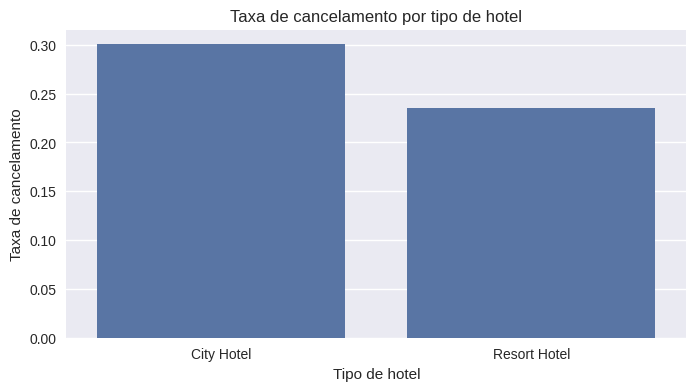

In [36]:
plt.figure(figsize=(8,4))
sns.barplot(x=resumo_hotel.index, y=resumo_hotel['taxa_cancelamento'].values)
plt.title('Taxa de cancelamento por tipo de hotel')
plt.ylabel('Taxa de cancelamento')
plt.xlabel('Tipo de hotel')
plt.show()

**Lead time vs taxa**

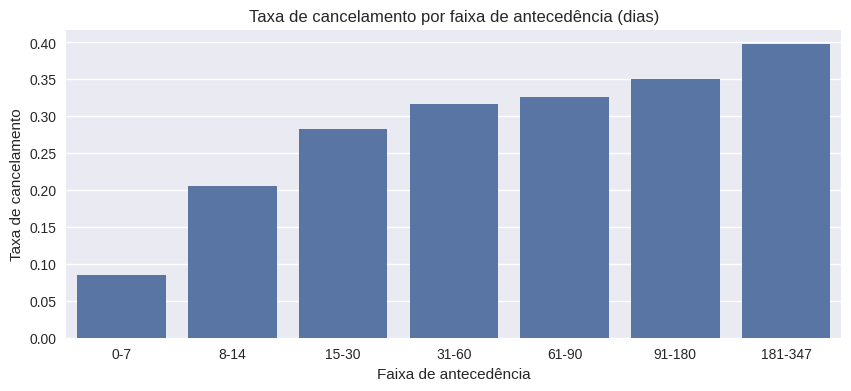

In [37]:
plt.figure(figsize=(10,4))
sns.barplot(x=resumo_antecedencia.index, y=resumo_antecedencia['taxa_cancelamento'].values)
plt.title('Taxa de cancelamento por faixa de antecedência (dias)')
plt.xlabel('Faixa de antecedência')
plt.ylabel('Taxa de cancelamento')
plt.show()

**Distribuição da tarifa diária média**

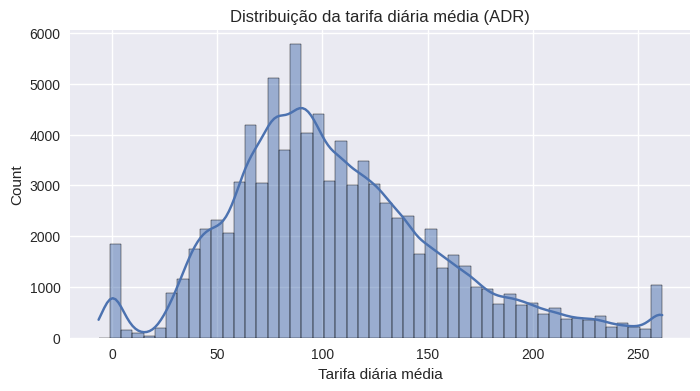

In [39]:
if 'tarifa_diaria_media' in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['tarifa_diaria_media'], bins=50, kde=True)
    plt.title('Distribuição da tarifa diária média (ADR)')
    plt.xlabel('Tarifa diária média')
    plt.show()

**Heatmap correlações numéricas**

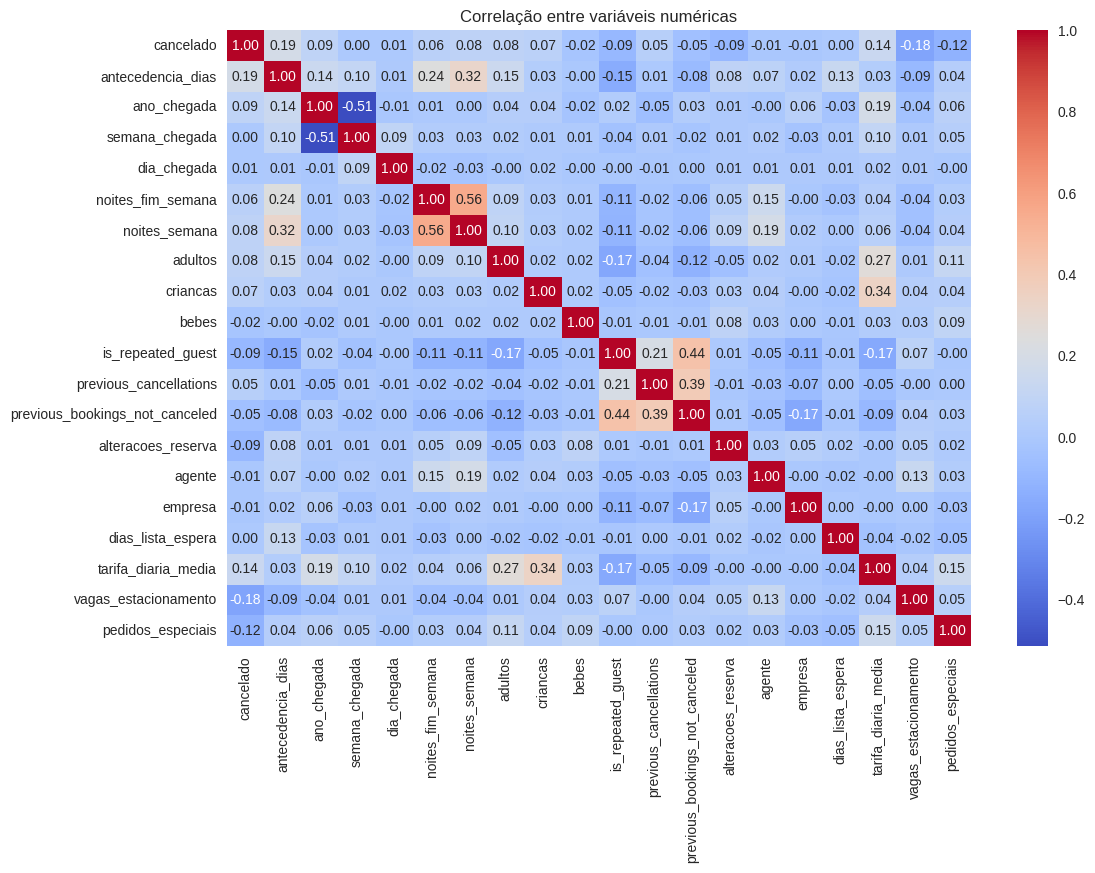

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis numéricas')
plt.show()

#Sazonalidade: reservas e cancelamentos por mês

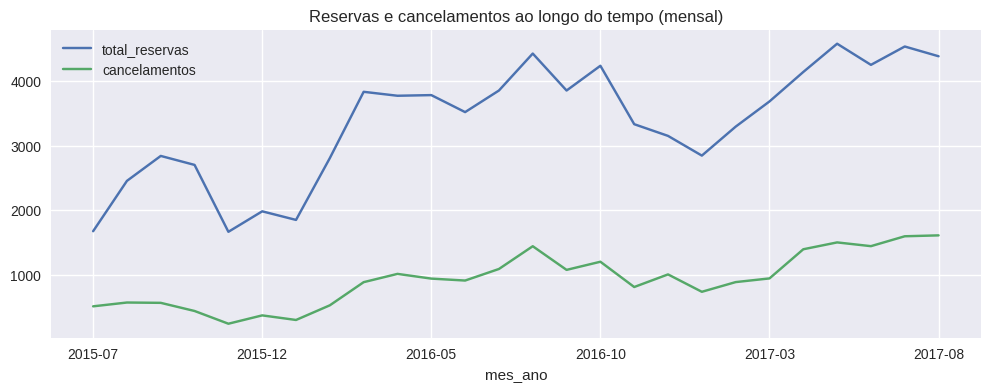

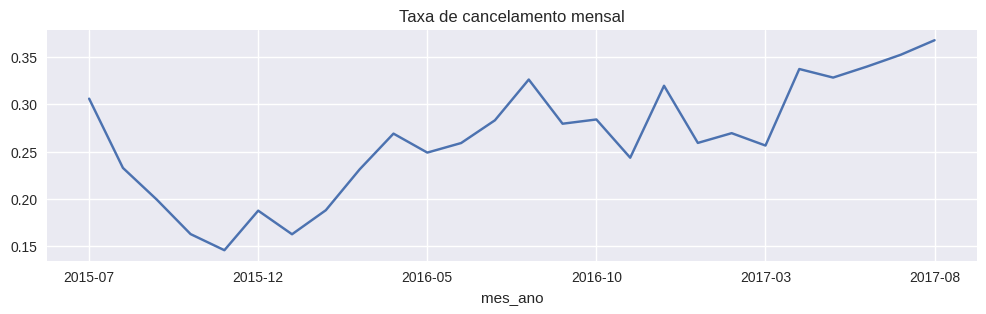

In [43]:
if 'data_chegada' in df.columns:
    df['mes_ano'] = df['data_chegada'].dt.to_period('M').astype(str)
    serie_mensal = df.groupby('mes_ano').agg(
    total_reservas=('cancelado','count'),
    cancelamentos=('cancelado','sum')
    ).assign(taxa_cancelamento=lambda x: x['cancelamentos']/x['total_reservas'])
    serie_mensal[['total_reservas','cancelamentos']].plot(figsize=(12,4))
    plt.title('Reservas e cancelamentos ao longo do tempo (mensal)')
    plt.show()
    serie_mensal['taxa_cancelamento'].plot(figsize=(12,3))
    plt.title('Taxa de cancelamento mensal')
    plt.show()

### Análise da Tarifa Diária Média (ADR) vs. Cancelamento

Vamos visualizar a distribuição da `tarifa_diaria_media` para reservas canceladas e não canceladas usando um boxplot. Isso nos ajudará a entender se há uma diferença significativa no ADR entre esses dois grupos.

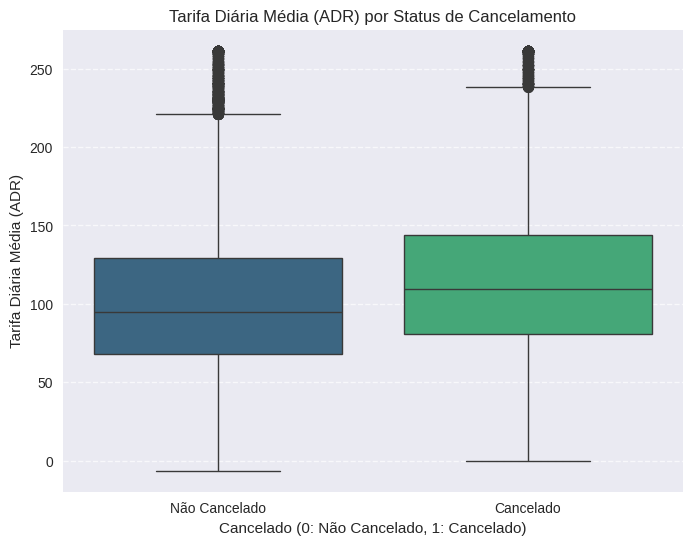

In [54]:
if 'tarifa_diaria_media' in df.columns and 'cancelado' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='cancelado', y='tarifa_diaria_media', data=df, palette='viridis')
    plt.title('Tarifa Diária Média (ADR) por Status de Cancelamento')
    plt.xlabel('Cancelado (0: Não Cancelado, 1: Cancelado)')
    plt.ylabel('Tarifa Diária Média (ADR)')
    plt.xticks([0, 1], ['Não Cancelado', 'Cancelado']) # Melhora os rótulos do eixo X
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Interpretação do Boxplot ADR vs. Cancelamento

Este boxplot mostra a distribuição da **Tarifa Diária Média (ADR)** para reservas que foram **canceladas (1)** e para as que **não foram canceladas (0)**. Ao observar a posição da mediana e a dispersão das caixas para cada grupo, podemos identificar se há uma tendência:

*   **Se a ADR mediana for mais alta para reservas canceladas:** Pode indicar que reservas mais caras ou de maior valor tendem a ser canceladas com mais frequência. Isso pode acontecer por diversos motivos, como clientes encontrando melhores ofertas, mudanças de planos para viagens de maior custo, etc.
*   **Se a ADR mediana for similar:** Sugere que a tarifa por si só pode não ser um fator dominante na decisão de cancelar a reserva.

Esta análise é útil para entender o perfil financeiro das reservas canceladas, complementando outras análises como as de antecedência e tipo de hotel.

#Freatures e modelagem preditiva

**Objetivo**: preparar features, separar treino/teste (80/20), treinar Random Forest e avaliar.

In [45]:
features = []
for c in ['hotel_tipo','antecedencia_dias','noites_fim_semana','noites_semana','adultos','criancas','bebes','regime','pais','segmento_mercado','canal_distribuicao','tipo_quarto_reservado','tipo_cliente','tarifa_diaria_media','pedidos_especiais']:
    if c in df.columns:
        features.append(c)

X = df[features].copy()
y = df['cancelado'].astype(int)

Preparando dados, separando as variáveis que serão usadas para prever (X) da variável (y), e garantindo que tudo esteja no formato correto para o treinamento de um modelo de machine learning.

**Tratando valores categóricos e numéricos separadamente**

In [46]:
cat_feats = X.select_dtypes(include=['object','category']).columns.tolist()
num_feats = X.select_dtypes(include=['int64','float64']).columns.tolist()

Essa separação é fundamental para as próximas etapas de pré-processamento, pois diferentes tipos de dados exigem diferentes técnicas de tratamento (por exemplo, OneHotEncoder para categóricos e StandardScaler para numéricos).

**Pipeline para pré-processamento**

In [48]:
preprocessor = ColumnTransformer(transformers=[
('num', StandardScaler(), num_feats),
('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
])

Padronização dos dados numéricos e transformação dos dados categóricos, deixando-os prontos para o treinamento de um modelo de Machine Learning.

**Divisão treino/teste 80/20**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Os dados foram divididos em 80% para treino (X_train, y_train) e 20% para teste (X_test, y_test). Isso garante que o modelo aprenda com a maioria dos dados e seja avaliado em dados novos.<br><br>
O random_state=42 garante que a divisão seja reproduzível.<br><br>
O stratify=y mantém a proporção da variável alvo (cancelado) em ambos os conjuntos, o que é importante para dados desbalanceados.<br><br>
Para o dataset, 80/20 é uma divisão adequada e comum, pois oferece dados suficientes para o treino e para uma avaliação robusta. 70/30 também seria válido, mas 80/20 aproveita um pouco mais os dados para o aprendizado do modelo, devido a quantidade de dados.

#Treinando Random Forest com pipeline

In [50]:
pipeline = Pipeline(steps=[
('preproc', preprocessor),
('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['antecedencia_dias',
                                                   'noites_fim_semana',
                                                   'noites_semana', 'adultos',
                                                   'criancas', 'bebes',
                                                   'tarifa_diaria_media',
                                                   'pedidos_especiais']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel_tipo', 'regime',
                                                   'pais', 'segmento_mercado',
                                                   'canal_distribuicao',
                                                   'tipo_quarto_reservado',
                                                   'tipo_cliente'])])),
                ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))])

Explicando: <br>
**preproc (Pré-processador):** É a primeira etapa do Pipeline. Ela se refere ao ColumnTransformer que foi definido anteriormente. Ele é responsável por:
<br>
**Padronizar (StandardScaler)** as features numéricas (antecedencia_dias, noites_fim_semana, etc.).<br>
**Codificar (OneHotEncoder)** as features categóricas (hotel_tipo, regime, pais, etc.) em um formato numérico que o modelo pode entender.<br>
**clf (Classificador):** Esta é a segunda e última etapa do Pipeline. Ela representa o seu modelo de Machine Learning, que é um RandomForestClassifier (um tipo de algoritmo que usa múltiplas árvores de decisão para fazer previsões).<br>
**n_estimators=100: **Significa que o Random Forest usará 100 árvores de decisão.<br>
**random_state=42:** Garante que os resultados sejam reproduzíveis.<br>
**n_jobs=-1:** Permite que o algoritmo use todos os núcleos do seu processador, acelerando o treinamento.<br>
**Quando é executado pipeline.fit(X_train, y_train):**<br>

O preprocessor é primeiro aplicado a X_train, transformando todas as features (numéricas são escaladas, categóricas são codificadas).<br>
Em seguida, o modelo RandomForestClassifier é treinado com essas features pré-processadas (X_train transformado) e a variável alvo (y_train).<br>
Em resumo, essa célula preparou automaticamente os dados de treino e depois usou esses dados preparados para treinar seu modelo Random Forest, tudo em uma única sequência organizada.

#Avaliação do modelo

In [51]:
y_pred = pipeline.predict(X_test)
print('Acurácia:', accuracy_score(y_test, y_pred))
print('Matriz de confusão:')
print(confusion_matrix(y_test, y_pred))
print('Relatório de classificação:')
print(classification_report(y_test, y_pred))

Acurácia: 0.8058924485125858
Matriz de confusão:
[[11429  1246]
 [ 2147  2658]]
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87     12675
           1       0.68      0.55      0.61      4805

    accuracy                           0.81     17480
   macro avg       0.76      0.73      0.74     17480
weighted avg       0.80      0.81      0.80     17480



### Visualização da Matriz de Confusão

Para uma compreensão visual mais clara dos resultados do modelo, podemos plotar a matriz de confusão.

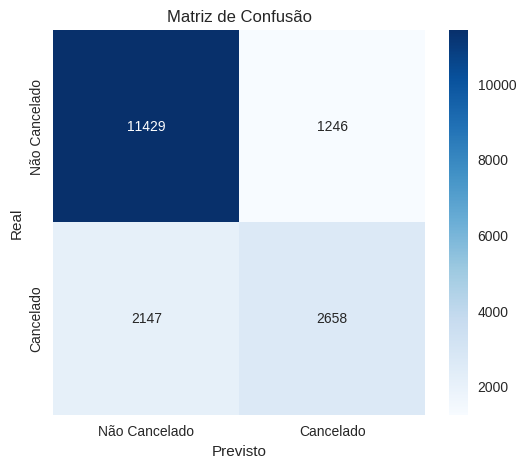

In [56]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelado', 'Cancelado'],
            yticklabels=['Não Cancelado', 'Cancelado'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

**Explicando resultados:**

y_pred = pipeline.predict(X_test): Usou o pipeline treinado (que inclui o pré-processamento e o RandomForestClassifier) para fazer previsões (y_pred) sobre o seu conjunto de teste (X_test). Essas são as predições do modelo.

**print('Acurácia:', accuracy_score(y_test, y_pred)):** Calculou a Acurácia do modelo. A acurácia mede a proporção de previsões corretas em relação ao total de previsões.

**print('Matriz de confusão:') e print(confusion_matrix(y_test, y_pred)):** Gerou a Matriz de Confusão. Esta matriz mostra detalhadamente onde o modelo acertou e errou para cada classe (cancelado ou não cancelado).

**[[11429, 1246], [2147, 2658]]:**

**11429 (Verdadeiros Negativos):** Reservas não canceladas que o modelo previu corretamente como não canceladas.

**1246 (Falsos Positivos):** Reservas não canceladas que o modelo previu incorretamente como canceladas.

**2147 (Falsos Negativos):** Reservas canceladas que o modelo previu incorretamente como não canceladas. (Este é um erro crítico, pois são cancelamentos reais que o modelo "perdeu").

**2658 (Verdadeiros Positivos):** Reservas canceladas que o modelo previu corretamente como canceladas.

**print('Relatório de classificação:') e print(classification_report(y_test, y_pred)):** Exibiu o Relatório de Classificação, que fornece métricas mais detalhadas por classe, como Precisão, Recall e F1-score.

#Possíveis Insights

Se taxa de cancelamento for maior em um tipo de hotel, investigue políticas de depósito e perfil de cliente (ex.: city vs resort). (resultado mostrado em resumo_hotel)

Se faixas de antecedência com maiores cancelamentos forem as longas, pode indicar reserva especulativa; se for nas curtíssimas, pode indicar imprevistos. (resumo_antecedencia)

Correlação entre tarifa_diaria_media e cancelamento: usar boxplots por is_canceled para ver se hóspedes que pagam menos/muito mais cancelam mais.

Países com altas taxas de cancelamento podem indicar necessidade de políticas diferentes por mercado (resumo_paises)

Importância de features: para RandomForest você pode extrair importâncias das features (após one-hot, mapeie nomes) para ver o que mais influencia cancelamentos.

#Extrair importâncias do RandomForest e mostrar top 15 features.

Obter nomes das colunas após OneHot

In [53]:
nomes_full = pipeline.named_steps['preproc'].get_feature_names_out().tolist()
importancias = pipeline.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature':nomes_full,'importancia':importancias}).sort_values('importancia',ascending=False).head(20)
imp_df

,feature,importancia
0,num__antecedencia_dias,0.245956
6,num__tarifa_diaria_media,0.202864
2,num__noites_semana,0.078046
7,num__pedidos_especiais,0.072186
1,num__noites_fim_semana,0.046085
145,cat__pais_PRT,0.045417
191,cat__segmento_mercado_Online TA,0.026511
3,num__adultos,0.023697
210,cat__tipo_cliente_Transient,0.014270
190,cat__segmento_mercado_Offline TA/TO,0.013144


**Explicação**: nomes_full = pipeline.named_steps['preproc'].get_feature_names_out().tolist():<br>
Esta linha obteve os nomes completos de todas as features após o pré-processamento (escalonamento dos numéricos e One-Hot Encoding dos categóricos).<br><br>
importancias = pipeline.named_steps['clf'].feature_importances_: Aqui, foi extraída a importância de cada feature diretamente do modelo <br><br>RandomForestClassifier (que está dentro do seu pipeline sob o nome 'clf'). O Random Forest atribui um peso a cada feature com base em como ela contribui para a redução da impureza (melhora das decisões) nas árvores.<br><br>
Criação e Ordenação do DataFrame (imp_df): As importâncias foram combinadas com os nomes das features em um DataFrame, que foi então ordenado de forma decrescente e limitado às 20 features mais importantes.

## Conclusão do Projeto hotel_bookingsAI

Este projeto realizou uma análise abrangente e a construção de um modelo preditivo para identificar reservas de hotéis com maior probabilidade de cancelamento. As principais etapas e achados incluem:

### 1. Tratamento e Preparação dos Dados
*   **Limpeza:** Foram removidas 31.994 linhas duplicadas e tratados valores ausentes, com `median` para colunas numéricas (ex: `criancas`, `agente`, `empresa`) e `mode` para categóricas (ex: `pais`).
*   **Engenharia de Features:** Criada a coluna `data_chegada` e `mes_ano` para análise temporal. Colunas importantes foram renomeadas para o português para maior clareza.
*   **Outliers:** Valores extremos em `tarifa_diaria_media` e `antecedencia_dias` foram mitigados utilizando *capping* no 99º percentil para garantir robustez nas análises e na modelagem.

### 2. Análise Exploratória de Dados (EDA)
*   **Taxas de Cancelamento:** Identificou-se que `City Hotels` possuem uma taxa de cancelamento ligeiramente maior. Países como Portugal (`PRT`) e China (`CHN`) apresentaram altas taxas de cancelamento. A antecedência da reserva (`antecedencia_dias`) mostrou uma clara correlação com o cancelamento, com taxas mais altas para reservas feitas com maior antecedência.
*   **Sazonalidade:** Gráficos de séries temporais revelaram padrões de reservas e cancelamentos ao longo dos meses.
*   **Relação ADR vs. Cancelamento:** Através de um boxplot, foi possível visualizar a distribuição da `tarifa_diaria_media` para reservas canceladas e não canceladas, indicando tendências sobre o perfil de custo das reservas canceladas.

### 3. Modelagem Preditiva
*   **Pipeline de ML:** Foi construído um pipeline robusto com `ColumnTransformer` para pré-processamento de features numéricas (StandardScaler) e categóricas (OneHotEncoder).
*   **Modelo:** Um `RandomForestClassifier` foi treinado para prever cancelamentos.
*   **Avaliação:** O modelo alcançou uma acurácia de aproximadamente 80.59%. A análise da matriz de confusão e do relatório de classificação destacou que o modelo tem um bom desempenho em identificar reservas que **não** serão canceladas (alto *recall* para classe 0), mas apresenta um *recall* moderado para identificar reservas que **serão** canceladas (55% para classe 1). Isso indica que o modelo ainda 'perde' uma parte significativa dos cancelamentos reais.
*   **Importância de Features:** As variáveis mais importantes para a previsão de cancelamento foram `antecedencia_dias` (lead time) e `tarifa_diaria_media` (ADR), seguidas por `noites_semana` e `pedidos_especiais`.

### Considerações Finais
O projeto demonstrou a capacidade de identificar padrões nos dados de reservas de hotéis que influenciam o cancelamento. Para futuras melhorias, a otimização do *recall* para a classe de cancelamento pode ser explorada através de técnicas de rebalanceamento de classes, ajuste de hiperparâmetros ou experimentação com outros modelos. Os *insights* gerados, especialmente sobre a antecedência e o ADR, são valiosos para a gestão hoteleira, permitindo a implementação de estratégias proativas para mitigar cancelamentos.